In [38]:
import utils
import numpy as np
import pandas as pd
import os
import re
from matplotlib.pyplot import cm
import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

In [39]:
# Make output folder
output_dir = os.path.join('..','..','plots','acoustic_simulations', 'planning')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [40]:
intensity_in_roi = pd.read_csv('/Volumes/project/3025011.02/TUS_simulations/planning/intensity_in_roi.csv')
print(intensity_in_roi)

    subject condition hemisphere      mean       std
0   sub-005     dense       left  2.540832  1.639660
1   sub-005     dense      right  3.808284  1.947064
2   sub-005    sparse       left  1.778726  1.503980
3   sub-005    sparse      right  2.484544  1.907951
4   sub-005  amygdala       left  1.967363  1.907052
5   sub-005  amygdala      right  1.880018  1.370629
6   sub-022     dense       left  3.305074  1.790877
7   sub-022     dense      right  4.089332  2.046128
8   sub-022    sparse       left  2.366136  1.630763
9   sub-022    sparse      right  2.980242  2.059616
10  sub-022  amygdala       left  1.599087  1.670601
11  sub-022  amygdala      right  1.134041  0.969133
12  sub-037     dense       left  2.764820  1.627077
13  sub-037     dense      right  3.952602  2.338849
14  sub-037    sparse       left  2.096147  1.539787
15  sub-037    sparse      right  2.690225  1.894450
16  sub-037  amygdala       left  2.073334  2.150695
17  sub-037  amygdala      right  2.051147  2.

         mean_dense_left  mean_dense_right  mean_sparse_left  \
subject                                                        
sub-005         2.540832          3.808284          1.778726   
sub-022         3.305074          4.089332          2.366136   
sub-037         2.764820          3.952602          2.096147   

         mean_sparse_right  std_dense_left  std_dense_right  std_sparse_left  \
subject                                                                        
sub-005           2.484544        1.639660         1.947064         1.503980   
sub-022           2.980242        1.790877         2.046128         1.630763   
sub-037           2.690225        1.627077         2.338849         1.539787   

         std_sparse_right  
subject                    
sub-005          1.907951  
sub-022          2.059616  
sub-037          1.894450  


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6257/3309349187.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intensity_in_roi_dacc['condition_hemisphere'] = intensity_in_roi_dacc['condition'] + '_' + intensity_in_roi_dacc['hemisphere']


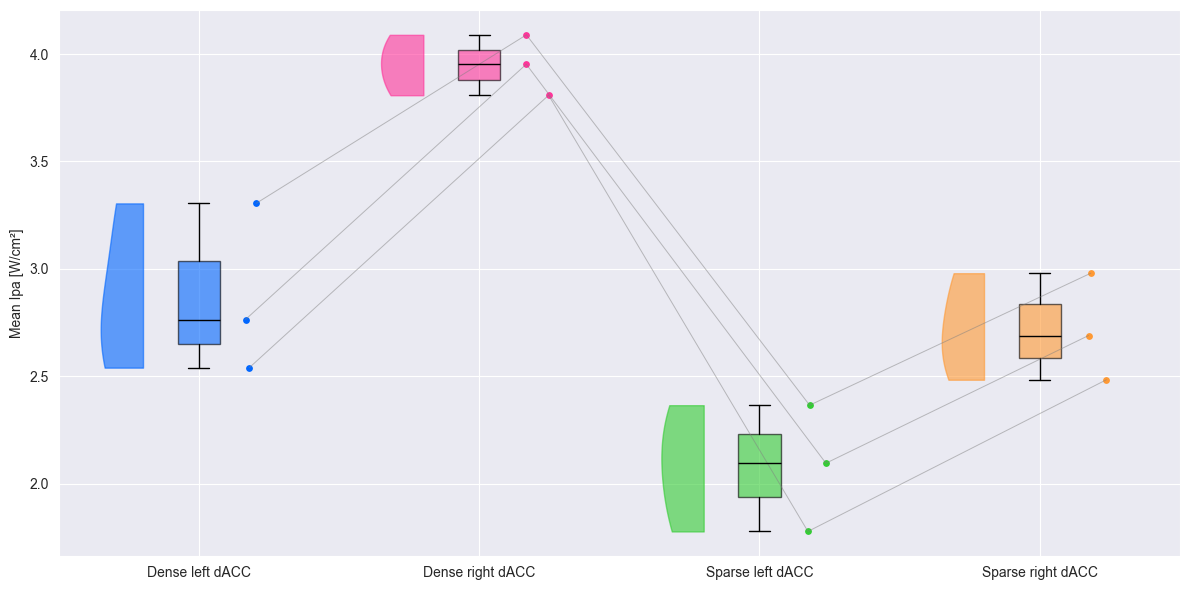

In [41]:
# Only look at the dACC conditions
intensity_in_roi_dacc = intensity_in_roi[intensity_in_roi['condition'] != 'amygdala']

#Create a combined column for condition and hemisphere
intensity_in_roi_dacc['condition_hemisphere'] = intensity_in_roi_dacc['condition'] + '_' + intensity_in_roi_dacc['hemisphere']

# Drop the original condition and hemisphere columns
intensity_in_roi_dacc = intensity_in_roi_dacc.drop(['condition', 'hemisphere'], axis=1)

# Pivot the data: subject as index, condition_hemisphere as columns
intensity_in_roi_dacc = intensity_in_roi_dacc.pivot(index='subject', columns='condition_hemisphere', values=['mean', 'std'])

# Flatten the multi-level column names
# This creates column names like 'mean_dense_left', 'mean_dense_right', etc.
intensity_in_roi_dacc.columns = [f'{stat}_{cond_hem}' for stat, cond_hem in intensity_in_roi_dacc.columns]

print(intensity_in_roi_dacc)

# Plot the four groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    intensity_in_roi_dacc,
    columns=['mean_dense_left','mean_dense_right','mean_sparse_left','mean_sparse_right'],
    labels=['Dense left dACC','Dense right dACC','Sparse left dACC','Sparse right dACC'],
    output_dir=output_dir,
    ylabel_name='Mean Ipa [W/cm²]',
    plot_name='Mean intensity in ROI by condition and hemisphere'
)

         mean_amygdala_left  mean_amygdala_right  std_amygdala_left  \
subject                                                               
sub-005            1.967363             1.880018           1.907052   
sub-022            1.599087             1.134041           1.670601   
sub-037            2.073334             2.051147           2.150695   

         std_amygdala_right  
subject                      
sub-005            1.370629  
sub-022            0.969133  
sub-037            2.155603  


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_6257/4287966428.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intensity_in_roi_amygdala['condition_hemisphere'] = intensity_in_roi_amygdala['condition'] + '_' + intensity_in_roi_amygdala['hemisphere']


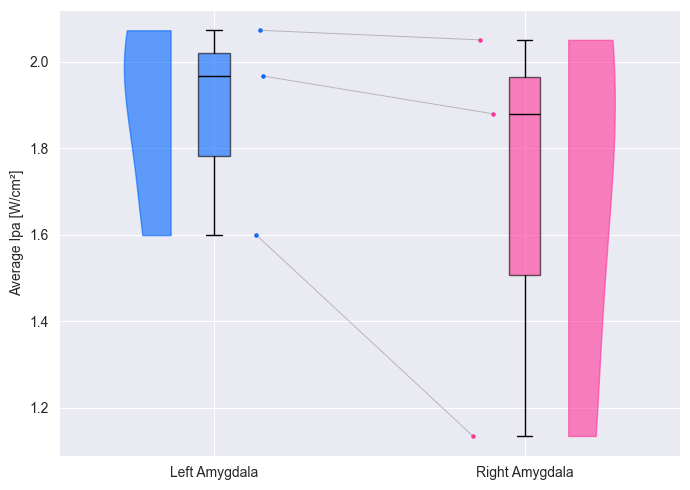

In [42]:
# Only look at the amygdala conditions
intensity_in_roi_amygdala = intensity_in_roi[intensity_in_roi['condition'] == 'amygdala']

#Create a combined column for condition and hemisphere
intensity_in_roi_amygdala['condition_hemisphere'] = intensity_in_roi_amygdala['condition'] + '_' + intensity_in_roi_amygdala['hemisphere']

# Drop the original condition and hemisphere columns
intensity_in_roi_amygdala = intensity_in_roi_amygdala.drop(['condition', 'hemisphere'], axis=1)

# Pivot the data: subject as index, condition_hemisphere as columns
intensity_in_roi_amygdala = intensity_in_roi_amygdala.pivot(index='subject', columns='condition_hemisphere', values=['mean', 'std'])

# Flatten the multi-level column names
# This creates column names like 'mean_dense_left', 'mean_dense_right', etc.
intensity_in_roi_amygdala.columns = [f'{stat}_{cond_hem}' for stat, cond_hem in intensity_in_roi_amygdala.columns]

print(intensity_in_roi_amygdala)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    intensity_in_roi_amygdala,
    column_1='mean_amygdala_left',
    column_2='mean_amygdala_right',
    labels=['Left Amygdala', 'Right Amygdala'],
    output_dir=output_dir,
    ylabel_name='Average Ipa [W/cm²]',
    plot_name='Average intensity in amygdala'
)

In [43]:
intensity_in_brain = pd.read_csv('/Volumes/project/3025011.02/TUS_simulations/planning/intensity_in_brain.csv')
print(intensity_in_brain)

   subject condition       min       max
0  sub-005     dense  0.000000  7.835159
1  sub-005    sparse -0.000009  7.886599
2  sub-022     dense -0.000303  8.442219
3  sub-022    sparse  0.000000  8.995294
4  sub-037     dense -0.000000  8.748957
5  sub-037    sparse -0.000000  8.130630


         min_max_dense  min_max_sparse  max_max_dense  max_max_sparse
subject                                                              
sub-005       0.000000       -0.000009       7.835159        7.886599
sub-022      -0.000303        0.000000       8.442219        8.995294
sub-037      -0.000000       -0.000000       8.748957        8.130630


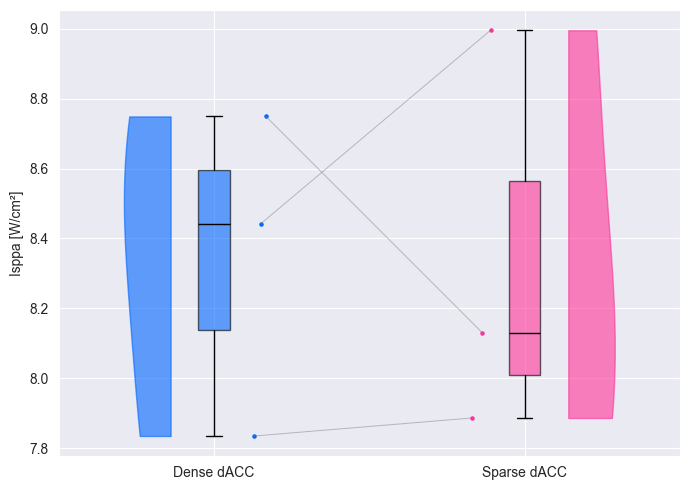

In [44]:
# Create a combined column for max and condition
intensity_in_brain['max_condition'] = 'max_' + intensity_in_brain['condition']

# Drop the condition column (keeping min and max values)
intensity_in_brain = intensity_in_brain.drop(['condition'], axis=1)

# Pivot the data: subject as index, max_condition as columns
intensity_in_brain = intensity_in_brain.pivot(index='subject', columns='max_condition', values=['min', 'max'])

# Flatten the multi-level column names
# This creates column names like 'min_max_dense', 'min_max_sparse', 'max_max_dense', 'max_max_sparse'
intensity_in_brain.columns = [f'{stat}_{cond}' for stat, cond in intensity_in_brain.columns]

print(intensity_in_brain)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    intensity_in_brain,
    column_1='max_max_dense',
    column_2='max_max_sparse',
    labels=['Dense dACC', 'Sparse dACC'],
    output_dir=output_dir,
    ylabel_name='Isppa [W/cm²]',
    plot_name='Max intensity in brain by condition'
)